# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

# Load Data

In [3]:
import pandas as pd

df = pd.read_csv(
    "SampleSuperstore.csv",
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Cleaning

In [6]:
df.info()

df.isnull().sum()

df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Overall Sales

In [7]:
total_sales = df['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


# Category-wise Sales

In [8]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum().sort_values()

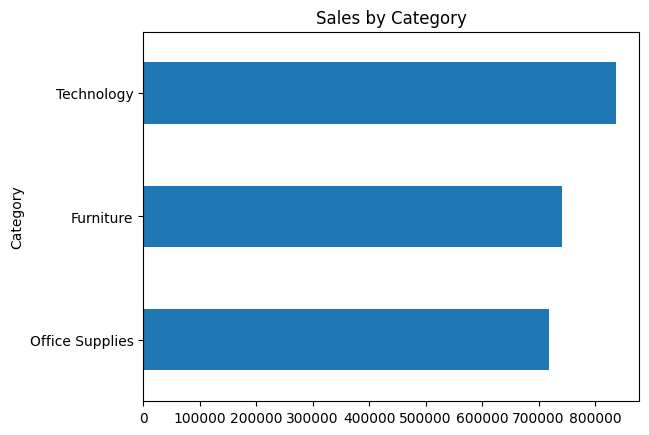

In [9]:
category_sales.plot(
    kind='barh'
)

plt.title("Sales by Category")

plt.show()

# Region-wise Sales

In [10]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

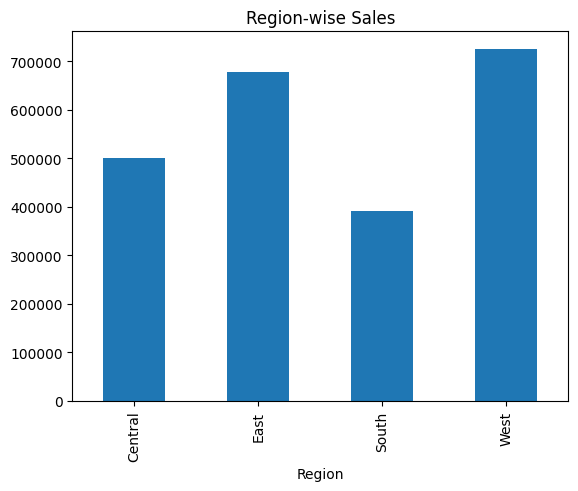

In [11]:
region_sales.plot(
    kind='bar'
)

plt.title("Region-wise Sales")

plt.show()

# Top Products

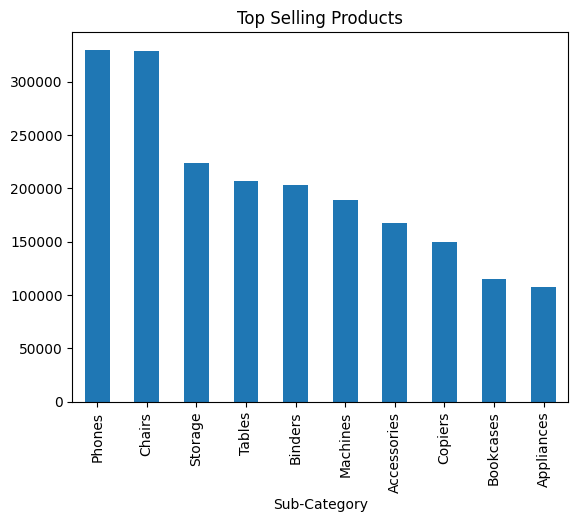

In [12]:
top_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

# Profit Analysis

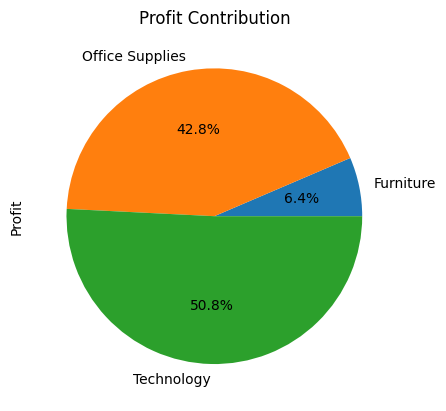

In [13]:
profit = (
    df.groupby('Category')
    ['Profit']
    .sum()
)

profit.plot(kind='pie',
            autopct='%1.1f%%')

plt.title("Profit Contribution")

plt.show()

# Correlation

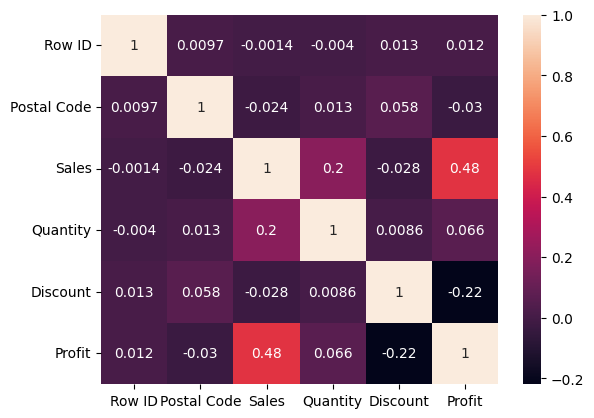

In [14]:
numeric = df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric.corr(),
    annot=True
)

plt.show()

# Sales Prediction

In [15]:
features = [
    'Quantity',
    'Discount',
    'Profit'
]

X = df[features]

y = df['Sales']

Train/Test Split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest

In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(
    X_test
)

Evaluation

In [19]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 101.78767428483496
R2 Score: 0.5545712660322168
